In [1]:
import pandas as pd
import ast

df = pd.read_csv("extended_dataset_2.csv")

/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_33283/3637982956.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("extended_dataset_2.csv")


In [2]:
df["parsed_og"] = df["og_string"].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else {}
)

df["genres"] = df["parsed_og"].apply(
    lambda x: x.get("genres", []) if isinstance(x, dict) else []
)

print(df["genres"].head(10))

0    [Action]
1    [Action]
2    [Action]
3    [Action]
4    [Action]
5    [Action]
6    [Action]
7    [Action]
8    [Action]
9    [Action]
Name: genres, dtype: object


In [3]:
from collections import Counter

genre_counter = Counter()

for genres in df["genres"]:
    if isinstance(genres, list):
        genre_counter.update(genres)

print(genre_counter.most_common(20))

[('Indie', 76014), ('Casual', 47085), ('Action', 43862), ('Adventure', 42709), ('Simulation', 22567), ('Strategy', 21211), ('RPG', 19757), ('Free To Play', 11413), ('Early Access', 9799), ('Sports', 4676), ('Racing', 3904), ('Massively Multiplayer', 2411), ('Utilities', 1012), ('Design & Illustration', 568), ('Animation & Modeling', 454), ('Education', 443), ('Violent', 403), ('Video Production', 330), ('Game Development', 310), ('Gore', 251)]


In [4]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["release_year"] = df["release_date"].dt.year

print(df["rec_storage"].describe())
print(df["min_storage"].describe())

count    2.660000e+02
mean     3.759398e+25
std      6.131393e+26
min      2.000000e-03
25%      5.000000e-01
50%      2.000000e+00
75%      4.000000e+00
max      1.000000e+28
Name: rec_storage, dtype: float64
count    9.964500e+04
mean     1.003563e+11
std      3.167906e+13
min      0.000000e+00
25%      3.000000e-01
50%      1.000000e+00
75%      3.000000e+00
max      1.000000e+16
Name: min_storage, dtype: float64


In [5]:
df["rec_storage_clean"] = df["rec_storage"].where(
    (df["rec_storage"] > 0) &
    (df["rec_storage"] < 500)
)

df["min_storage_clean"] = df["min_storage"].where(
    (df["min_storage"] > 0) &
    (df["min_storage"] < 500)
)

print(df["rec_storage_clean"].describe())
print(df["min_storage_clean"].describe())

count    264.000000
mean       5.535533
std       17.747445
min        0.002000
25%        0.500000
50%        2.000000
75%        4.000000
max      161.000000
Name: rec_storage_clean, dtype: float64
count    99614.000000
mean         3.168018
std          9.493106
min          0.000520
25%          0.300000
50%          1.000000
75%          3.000000
max        475.000000
Name: min_storage_clean, dtype: float64


In [8]:
df_exploded = df.explode("genres")

selected_genres = [
    "Action",
    "Adventure",
    "RPG",
    "Simulation",
    "Strategy",
    "Indie"
]

filtered = df_exploded[
    (df_exploded["genres"].isin(selected_genres)) &
    (df_exploded["release_year"] >= 2005)
]

genre_trends = (
    filtered.groupby(["release_year", "genres"])["min_storage_clean"]
    .mean()
    .reset_index()
)

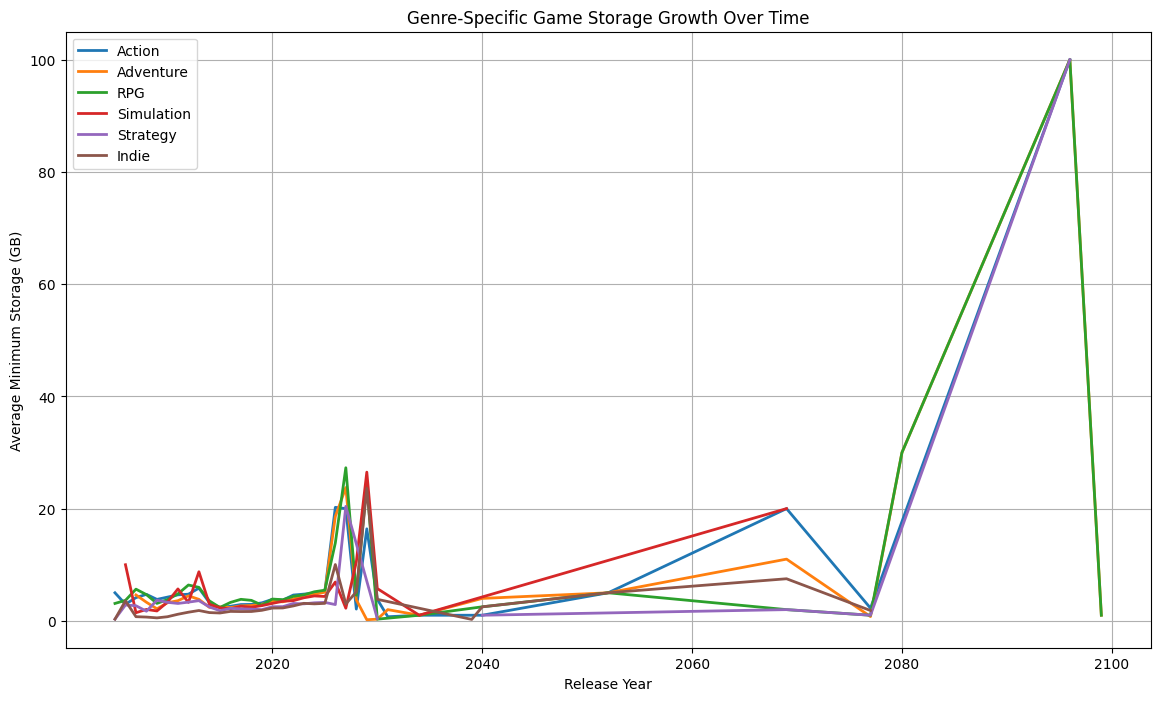

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for genre in selected_genres:
    
    subset = genre_trends[
        genre_trends["genres"] == genre
    ]
    
    plt.plot(
        subset["release_year"],
        subset["min_storage_clean"],
        label=genre,
        linewidth=2
    )

plt.xlabel("Release Year")
plt.ylabel("Average Minimum Storage (GB)")
plt.title("Genre-Specific Game Storage Growth Over Time")

plt.legend()
plt.grid(True)

plt.show()

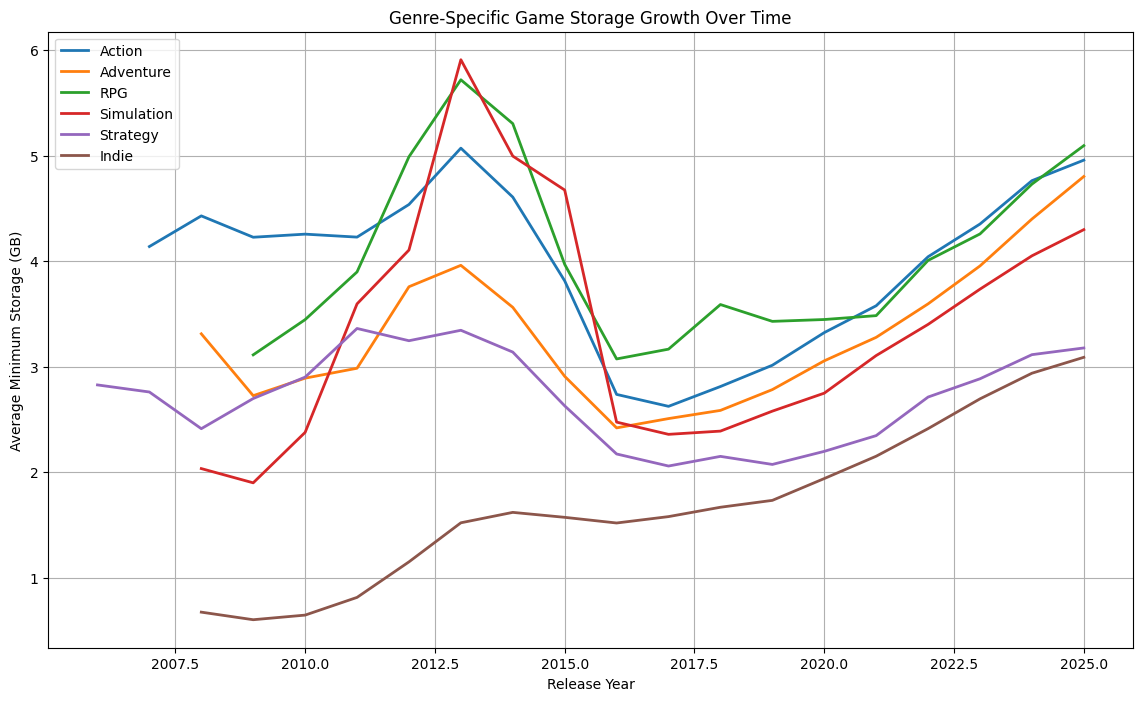

In [10]:
filtered = filtered[
    (filtered["release_year"] >= 2005) &
    (filtered["release_year"] <= 2025)
]

counts = (
    filtered.groupby(["release_year", "genres"])
    .size()
    .reset_index(name="count")
)

genre_trends = (
    filtered.groupby(["release_year", "genres"])["min_storage_clean"]
    .mean()
    .reset_index()
)

genre_trends = genre_trends.merge(
    counts,
    on=["release_year", "genres"]
)

genre_trends = genre_trends[
    genre_trends["count"] >= 20
]

plt.figure(figsize=(14,8))

for genre in selected_genres:

    subset = genre_trends[
        genre_trends["genres"] == genre
    ].sort_values("release_year")

    subset["smoothed"] = (
        subset["min_storage_clean"]
        .rolling(window=3, min_periods=1)
        .mean()
    )

    plt.plot(
        subset["release_year"],
        subset["smoothed"],
        label=genre,
        linewidth=2
    )

plt.xlabel("Release Year")
plt.ylabel("Average Minimum Storage (GB)")
plt.title("Genre-Specific Game Storage Growth Over Time")

plt.legend()
plt.grid(True)

plt.show()

# 1. Genre - storage boxplot
# 2. Genre - mean vs median trend
# 3. RAM vs storage

/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_33283/4123391456.py:11: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("extended_dataset_2.csv")


Minimum storage summary:
count    99427.000000
mean         3.153141
std          9.337895
min          0.000520
25%          0.300000
50%          1.000000
75%          3.000000
max        458.000000
Name: min_storage_clean, dtype: float64

Recommended storage summary:
count    255.000000
mean       5.574042
std       18.056372
min        0.002000
25%        0.500000
50%        2.000000
75%        4.000000
max      161.000000
Name: rec_storage_clean, dtype: float64


<Figure size 1200x600 with 0 Axes>

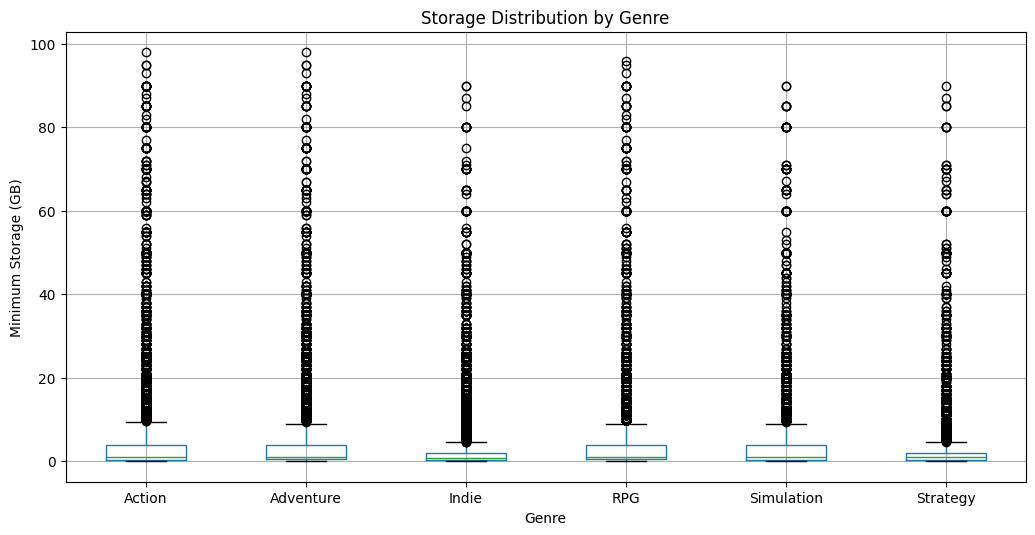

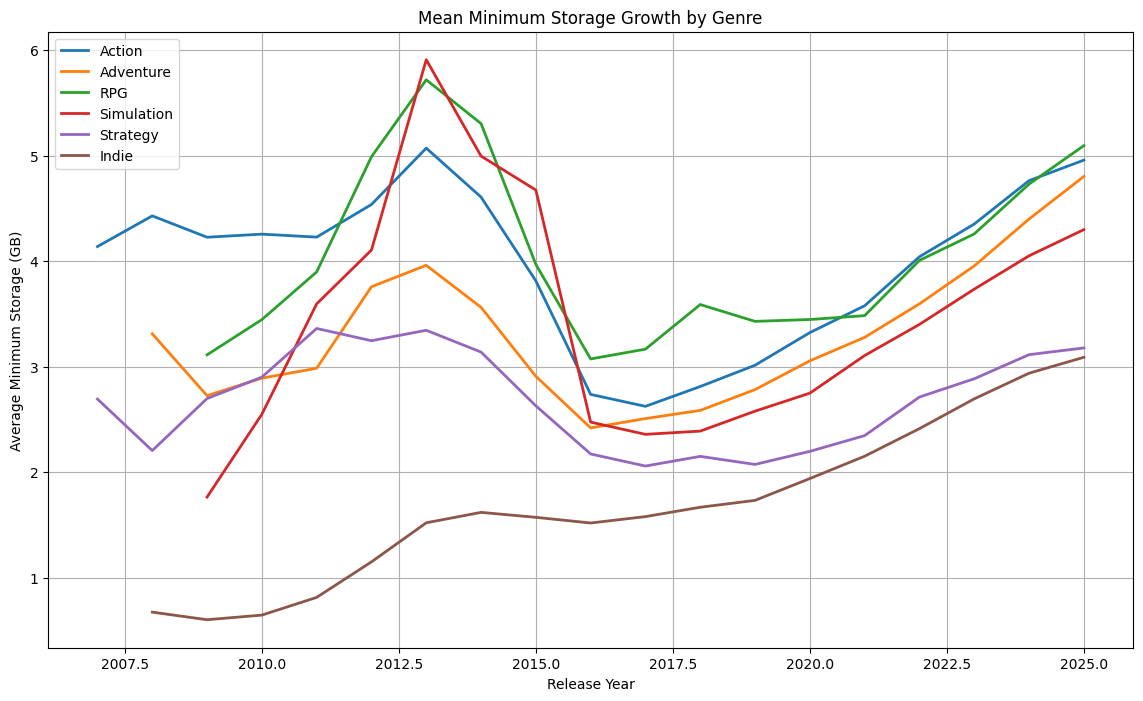

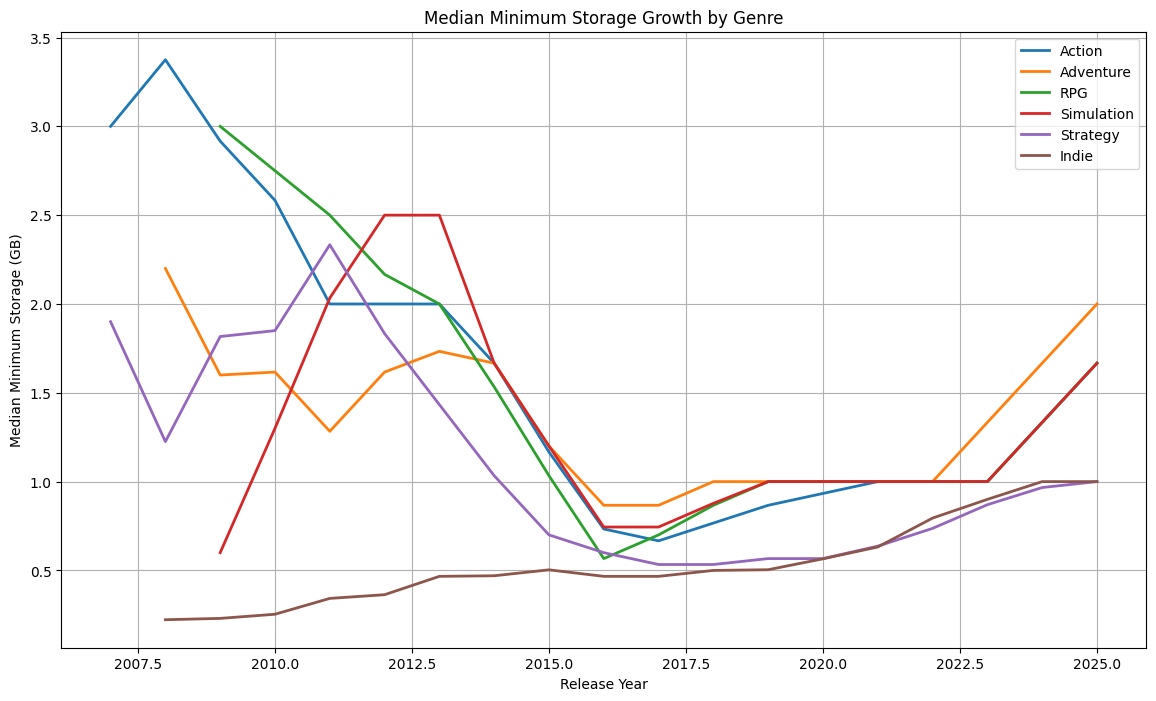


Minimum RAM summary:
count    100333.000000
mean          3.638642
std           3.678574
min           0.000977
25%           1.000000
50%           2.000000
75%           4.000000
max         256.000000
Name: min_ram_gb_clean, dtype: float64

Recommended RAM summary:
count    51359.000000
mean         7.367371
std          7.558534
min          0.000977
25%          3.000000
50%          8.000000
75%          8.000000
max        256.000000
Name: rec_ram_gb_clean, dtype: float64

RAM-storage correlation:
                   min_storage_clean  min_ram_gb_clean
min_storage_clean           1.000000          0.302425
min_ram_gb_clean            0.302425          1.000000


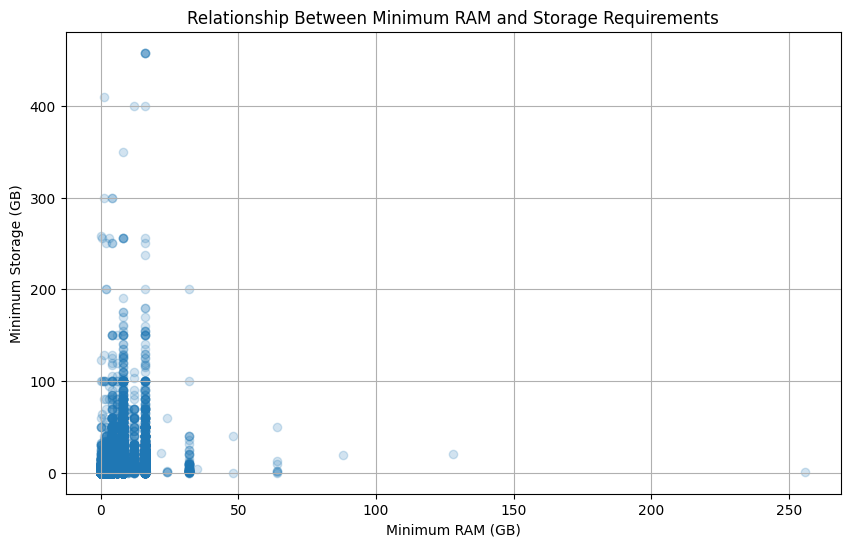

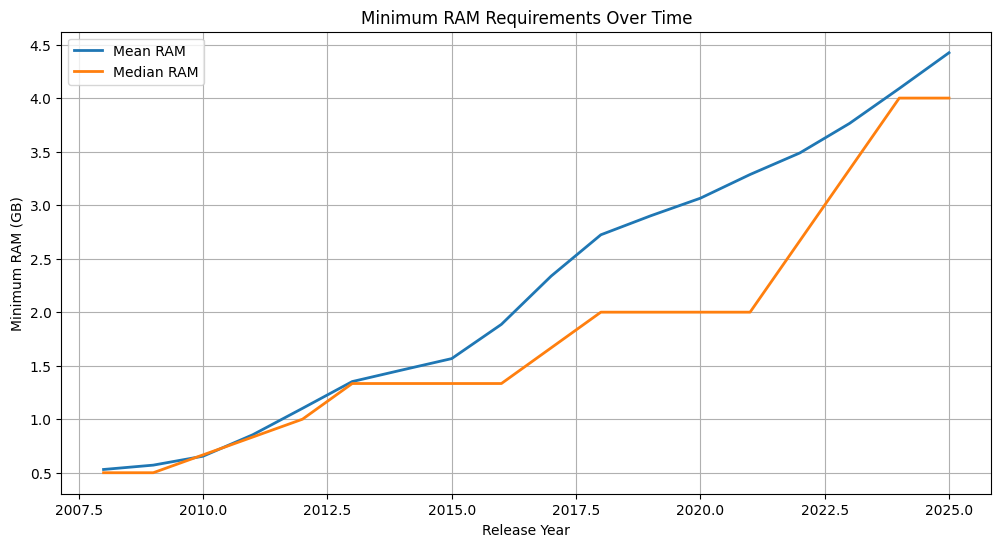

In [11]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt

# ============================================================
# 0. Load dataset
# ============================================================

df = pd.read_csv("extended_dataset_2.csv")

# ============================================================
# 1. Parse og_string and extract genres
# ============================================================

def parse_og_string(x):
    if pd.isna(x):
        return {}
    try:
        return ast.literal_eval(x)
    except:
        return {}

df["parsed_og"] = df["og_string"].apply(parse_og_string)

df["genres"] = df["parsed_og"].apply(
    lambda x: x.get("genres", []) if isinstance(x, dict) else []
)

# ============================================================
# 2. Clean release year
# ============================================================

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# Keep realistic release years only
df = df[
    (df["release_year"] >= 2005) &
    (df["release_year"] <= 2025)
].copy()

# ============================================================
# 3. Clean storage values
# ============================================================

df["min_storage_clean"] = df["min_storage"].where(
    (df["min_storage"] > 0) &
    (df["min_storage"] < 500)
)

df["rec_storage_clean"] = df["rec_storage"].where(
    (df["rec_storage"] > 0) &
    (df["rec_storage"] < 500)
)

# Main analysis uses min_storage_clean because rec_storage is sparse
print("Minimum storage summary:")
print(df["min_storage_clean"].describe())

print("\nRecommended storage summary:")
print(df["rec_storage_clean"].describe())

# ============================================================
# 4. Select genres and explode genre list
# ============================================================

selected_genres = [
    "Action",
    "Adventure",
    "RPG",
    "Simulation",
    "Strategy",
    "Indie"
]

df_exploded = df.explode("genres")

filtered = df_exploded[
    (df_exploded["genres"].isin(selected_genres)) &
    (df_exploded["min_storage_clean"].notna())
].copy()

# ============================================================
# 5. Analysis 1: Genre storage distribution boxplot
# ============================================================

boxplot_df = filtered[
    filtered["min_storage_clean"] < 100
].copy()

plt.figure(figsize=(12, 6))

boxplot_df.boxplot(
    column="min_storage_clean",
    by="genres",
    figsize=(12, 6)
)

plt.title("Storage Distribution by Genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Minimum Storage (GB)")
plt.grid(True)

plt.show()

# ============================================================
# 6. Analysis 2: Mean vs Median storage trend by genre
# ============================================================

genre_stats = (
    filtered
    .groupby(["release_year", "genres"])["min_storage_clean"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

# Remove unstable year-genre groups with too few samples
genre_stats = genre_stats[
    genre_stats["count"] >= 20
].copy()

# Rolling smoothing
genre_stats = genre_stats.sort_values(["genres", "release_year"])

genre_stats["mean_smoothed"] = (
    genre_stats
    .groupby("genres")["mean"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

genre_stats["median_smoothed"] = (
    genre_stats
    .groupby("genres")["median"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Mean trend plot
plt.figure(figsize=(14, 8))

for genre in selected_genres:
    subset = genre_stats[genre_stats["genres"] == genre]
    plt.plot(
        subset["release_year"],
        subset["mean_smoothed"],
        label=genre,
        linewidth=2
    )

plt.xlabel("Release Year")
plt.ylabel("Average Minimum Storage (GB)")
plt.title("Mean Minimum Storage Growth by Genre")
plt.legend()
plt.grid(True)

plt.show()

# Median trend plot
plt.figure(figsize=(14, 8))

for genre in selected_genres:
    subset = genre_stats[genre_stats["genres"] == genre]
    plt.plot(
        subset["release_year"],
        subset["median_smoothed"],
        label=genre,
        linewidth=2
    )

plt.xlabel("Release Year")
plt.ylabel("Median Minimum Storage (GB)")
plt.title("Median Minimum Storage Growth by Genre")
plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# 7. Analysis 3: Parse RAM values
# ============================================================

def parse_ram_to_gb(x):
    if pd.isna(x):
        return np.nan
    
    text = str(x).lower()
    
    # Remove commas
    text = text.replace(",", "")
    
    # Match GB
    gb_match = re.search(r"(\d+(\.\d+)?)\s*gb", text)
    if gb_match:
        return float(gb_match.group(1))
    
    # Match MB
    mb_match = re.search(r"(\d+(\.\d+)?)\s*mb", text)
    if mb_match:
        return float(mb_match.group(1)) / 1024
    
    return np.nan

df["min_ram_gb"] = df["mat_pc_memory_min"].apply(parse_ram_to_gb)
df["rec_ram_gb"] = df["mat_pc_memory_rec"].apply(parse_ram_to_gb)

# Clean unrealistic RAM values
df["min_ram_gb_clean"] = df["min_ram_gb"].where(
    (df["min_ram_gb"] > 0) &
    (df["min_ram_gb"] <= 256)
)

df["rec_ram_gb_clean"] = df["rec_ram_gb"].where(
    (df["rec_ram_gb"] > 0) &
    (df["rec_ram_gb"] <= 256)
)

print("\nMinimum RAM summary:")
print(df["min_ram_gb_clean"].describe())

print("\nRecommended RAM summary:")
print(df["rec_ram_gb_clean"].describe())

# ============================================================
# 8. RAM vs storage correlation
# ============================================================

ram_storage_df = df[
    df["min_storage_clean"].notna() &
    df["min_ram_gb_clean"].notna()
].copy()

print("\nRAM-storage correlation:")
print(
    ram_storage_df[["min_storage_clean", "min_ram_gb_clean"]]
    .corr()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    ram_storage_df["min_ram_gb_clean"],
    ram_storage_df["min_storage_clean"],
    alpha=0.2
)

plt.xlabel("Minimum RAM (GB)")
plt.ylabel("Minimum Storage (GB)")
plt.title("Relationship Between Minimum RAM and Storage Requirements")
plt.grid(True)

plt.show()

# ============================================================
# 9. RAM trend over time
# ============================================================

ram_trend = (
    df[df["min_ram_gb_clean"].notna()]
    .groupby("release_year")["min_ram_gb_clean"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

ram_trend = ram_trend[
    ram_trend["count"] >= 20
].copy()

ram_trend["mean_smoothed"] = (
    ram_trend["mean"]
    .rolling(window=3, min_periods=1)
    .mean()
)

ram_trend["median_smoothed"] = (
    ram_trend["median"]
    .rolling(window=3, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    ram_trend["release_year"],
    ram_trend["mean_smoothed"],
    label="Mean RAM",
    linewidth=2
)

plt.plot(
    ram_trend["release_year"],
    ram_trend["median_smoothed"],
    label="Median RAM",
    linewidth=2
)

plt.xlabel("Release Year")
plt.ylabel("Minimum RAM (GB)")
plt.title("Minimum RAM Requirements Over Time")
plt.legend()
plt.grid(True)

plt.show()